# 06 · Comprehensive scoring

Score every available CV forecast against the held-out actuals using:

1. **Bottom-level WRMSSE** — official competition metric at item × store (`m5.evaluation`).
2. **Hierarchical WRMSSE** — re-aggregated across the 12 official M5 hierarchy levels.
3. **Standard accuracy metrics** — MAE, RMSE, sMAPE, signed bias.
4. **Per-series diagnostics** — RMSSE distribution, worst offenders, bias by category/state.
5. **Predicted vs actual** — network total per CV window + top-volume series.

**Inputs**
- `data/processed/long.parquet` — produced by `make prep`.
- `artifacts/cv_*.parquet` — rolling-origin CV outputs from `make cv-stats` / `make cv-lgbm`.
  Schema: `unique_id, ds, y, cutoff, <model_cols...>` (Nixtla convention).

Drop additional CV parquets in `artifacts/` matching `cv_*.parquet` and they are picked up automatically.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from __future__ import annotations
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from m5.config import SETTINGS
from m5.evaluation import compute_components, wrmsse_for_models
from m5.logging import logger
from m5.plots import configure_style

configure_style()

ARTIFACTS = SETTINGS.artifacts_dir
LONG_PARQUET = SETTINGS.processed_dir / 'long.parquet'
SCORING_OUT = ARTIFACTS / 'scoring_summary.parquet'

print(f'artifacts dir: {ARTIFACTS}')
print(f'long parquet:  {LONG_PARQUET}  exists={LONG_PARQUET.exists()}')

artifacts dir: /home/ricka/Git/GitHub/M5/artifacts
long parquet:  data/processed/long.parquet  exists=True


## 1 · Load truth and prediction sets

In [3]:
if not LONG_PARQUET.exists():
    raise FileNotFoundError(f'Run `make prep` first — expected {LONG_PARQUET} but it does not exist.')

long = pd.read_parquet(LONG_PARQUET)
keep = ['unique_id', 'ds', 'y', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id']
if 'sell_price' in long.columns:
    keep.append('sell_price')
long = long[keep].sort_values(['unique_id', 'ds']).reset_index(drop=True)
print(
    f'long: {len(long):,d} rows, '
    f'{long.unique_id.nunique():,d} series, '
    f'{long.ds.nunique():,d} days '
    f'({long.ds.min().date()} -> {long.ds.max().date()})'
)
long.head()

long: 1,004,671 rows, 5,000 series, 201 days (2015-11-04 -> 2016-05-22)


,unique_id,ds,y,item_id,dept_id,cat_id,store_id,state_id,sell_price
0,FOODS_1_001_CA_1,2015-11-04,0.0,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,2.24
1,FOODS_1_001_CA_1,2015-11-05,0.0,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,2.24
2,FOODS_1_001_CA_1,2015-11-06,0.0,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,2.24
3,FOODS_1_001_CA_1,2015-11-07,1.0,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,2.24
4,FOODS_1_001_CA_1,2015-11-08,0.0,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,2.24


In [4]:
def discover_prediction_sets(directory: Path, pattern: str = 'cv_*.parquet') -> dict[str, Path]:
    found = {p.stem.removeprefix('cv_'): p for p in sorted(directory.glob(pattern))}
    if not found:
        logger.warning(
            f'No prediction sets matched {directory}/{pattern}. '
            'Run `make cv-stats` / `make cv-lgbm` first.'
        )
    return found


paths = discover_prediction_sets(ARTIFACTS)
for name, p in paths.items():
    print(f'  {name:<10s} -> {p.relative_to(SETTINGS.artifacts_dir.parent)}')

  hier       -> artifacts/cv_hier.parquet
  lgbm       -> artifacts/cv_lgbm.parquet
  stats      -> artifacts/cv_stats.parquet


In [5]:
def load_cv_predictions(paths: dict[str, Path]) -> tuple[pd.DataFrame, list[str]]:
    """Outer-merge every CV parquet on (unique_id, ds, cutoff). Returns (frame, model_cols)."""
    if not paths:
        return pd.DataFrame(), []
    keys = ['unique_id', 'ds', 'cutoff']
    raw_cols_by_set = {
        name: [c for c in pd.read_parquet(path).columns if c not in (*keys, 'y')]
        for name, path in paths.items()
    }
    all_raw_cols = [c for cols in raw_cols_by_set.values() for c in cols]
    duplicate_cols = {c for c in all_raw_cols if all_raw_cols.count(c) > 1}

    base: pd.DataFrame | None = None
    model_cols: list[str] = []
    for name, path in paths.items():
        cv = pd.read_parquet(path)
        new_cols = raw_cols_by_set[name]
        rename = {c: f'{name}:{c}' for c in new_cols if c in duplicate_cols}
        renamed_cols = [rename.get(c, c) for c in new_cols]
        model_cols.extend(renamed_cols)
        cols = [*keys, 'y', *new_cols] if base is None else [*keys, *new_cols]
        part = cv[cols].rename(columns=rename)
        base = part.copy() if base is None else base.merge(part, on=keys, how='outer')
    assert base is not None
    return base, sorted(set(model_cols))


cv, model_cols = load_cv_predictions(paths)
if cv.empty:
    raise RuntimeError('No prediction sets found. Run `make cv-stats` / `make cv-lgbm`.')

horizon_days = (cv['ds'] - cv['cutoff']).dt.days
print(f'merged eval frame: {len(cv):,d} rows × {cv.shape[1]} cols')
print(f'models:    {model_cols}')
print(f'cutoffs:   {sorted(pd.to_datetime(cv.cutoff.unique()))}')
print(f'horizon:   day {horizon_days.min()} -> day {horizon_days.max()}')
cv.head()

merged eval frame: 2,561,160 rows × 12 cols
models:    ['AutoETS', 'LGBM', 'SeasonalNaive', 'Theta/BottomUp', 'Theta/MinTrace_method-mint_shrink', 'Theta/MinTrace_method-ols', 'hier:Theta', 'stats:Theta']
cutoffs:   [Timestamp('2016-02-28 00:00:00'), Timestamp('2016-03-27 00:00:00'), Timestamp('2016-04-24 00:00:00')]
horizon:   day 1 -> day 28


,unique_id,ds,cutoff,y,hier:Theta,Theta/BottomUp,Theta/MinTrace_method-ols,Theta/MinTrace_method-mint_shrink,LGBM,stats:Theta,AutoETS,SeasonalNaive
0,FOODS_1_001_CA_1,2016-02-29,2016-02-28,1.0,0.434702,0.434702,0.562539,0.471077,0.472250,0.448120,0.469994,0.0
1,FOODS_1_001_CA_1,2016-03-01,2016-02-28,0.0,0.433575,0.433575,0.656618,0.470525,0.491295,0.448335,0.535958,1.0
2,FOODS_1_001_CA_1,2016-03-02,2016-02-28,1.0,0.432447,0.432447,0.550127,0.457663,0.540449,0.448549,0.577652,0.0
3,FOODS_1_001_CA_1,2016-03-03,2016-02-28,0.0,0.431319,0.431319,0.664668,0.468966,0.686279,0.448763,0.592263,0.0
4,FOODS_1_001_CA_1,2016-03-04,2016-02-28,0.0,0.430192,0.430192,0.589389,0.452652,0.721863,0.448978,0.665826,0.0


## 2 · Bottom-level WRMSSE leaderboard

In [6]:
# Components are computed on training history strictly before the first CV window.
# Nixtla's `cutoff` is the last training day; predictions begin at cutoff + 1.
train_cutoff = cv['cutoff'].min()
train_for_components = long[long['ds'] <= train_cutoff].copy()
if train_for_components.empty:
    raise ValueError(f'No training data on or before first CV cutoff {train_cutoff}.')

print(
    f'components computed on {len(train_for_components):,d} rows ending '
    f'{train_for_components.ds.max().date()} (<= first cutoff {pd.Timestamp(train_cutoff).date()})'
)
components = compute_components(train_for_components)
print(f'weights: {len(components.weights):,d} series, sum={components.weights.sum():.4f}')
print(f'scales:  {len(components.scales):,d} series (zeros and NaNs dropped)')

components computed on 584,671 rows ending 2016-02-28 (<= first cutoff 2016-02-28)
weights: 4,882 series, sum=1.0000
scales:  4,882 series (zeros and NaNs dropped)


In [7]:
truth = cv[['unique_id', 'ds', 'y']].dropna(subset=['y'])
bottom_scores = wrmsse_for_models(truth, cv, components, model_cols=model_cols)
leaderboard = (bottom_scores.to_frame('WRMSSE_bottom')
               .assign(rank=lambda d: d['WRMSSE_bottom'].rank(method='min').astype(int)))
leaderboard

,WRMSSE_bottom,rank
LGBM,0.800514,1
AutoETS,0.814750,2
stats:Theta,0.821237,3
Theta/MinTrace_method-mint_shrink,0.829401,4
hier:Theta,0.833672,5
Theta/BottomUp,0.833672,6
Theta/MinTrace_method-ols,0.834082,7
SeasonalNaive,1.048186,8


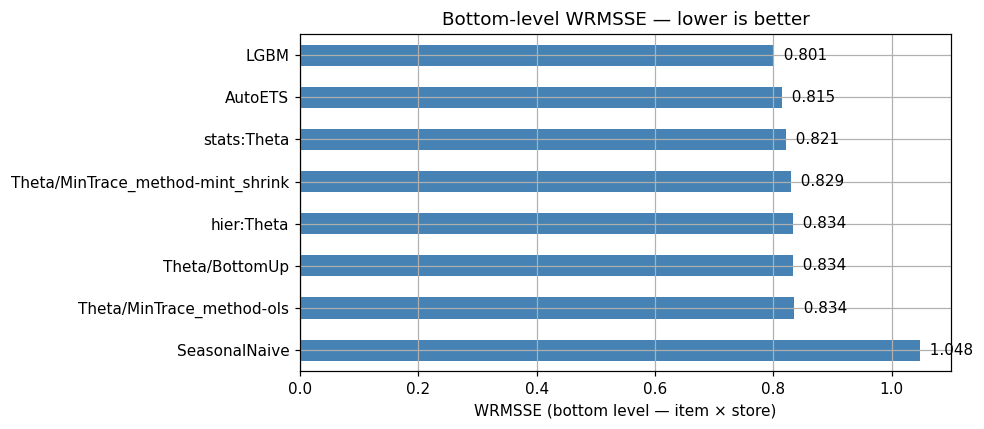

In [8]:
fig, ax = plt.subplots(figsize=(9, max(3, 0.5 * len(bottom_scores))))
sorted_scores = bottom_scores.sort_values()
sorted_scores.plot.barh(ax=ax, color='steelblue')
ax.set_xlabel('WRMSSE (bottom level — item × store)')
ax.set_title('Bottom-level WRMSSE — lower is better')
for i, v in enumerate(sorted_scores.values):
    ax.text(v, i, f'  {v:.3f}', va='center')
ax.invert_yaxis()
fig.tight_layout()

## 3 · Hierarchical WRMSSE across the 12 M5 levels

`m5.evaluation.wrmsse` only scores the bottom (item × store) level. The official M5 metric is the 
average WRMSSE across 12 levels. The helper below re-aggregates truth and forecasts to each level, 
sums bottom-level dollar-sales weights into groups (so the weighting stays consistent), and computes 
RMSSE on the aggregated series scaled by Naive-1 MSE on the aggregated *training* series.

In [9]:
M5_LEVELS: list[tuple[str, list[str]]] = [
    ('L1_total',        []),
    ('L2_state',        ['state_id']),
    ('L3_store',        ['store_id']),
    ('L4_cat',          ['cat_id']),
    ('L5_dept',         ['dept_id']),
    ('L6_state_cat',    ['state_id', 'cat_id']),
    ('L7_state_dept',   ['state_id', 'dept_id']),
    ('L8_store_cat',    ['store_id', 'cat_id']),
    ('L9_store_dept',   ['store_id', 'dept_id']),
    ('L10_item',        ['item_id']),
    ('L11_item_state',  ['item_id', 'state_id']),
    ('L12_item_store',  ['item_id', 'store_id']),
]

STATIC_COLS = ['item_id', 'dept_id', 'cat_id', 'store_id', 'state_id']
statics = long[['unique_id', *STATIC_COLS]].drop_duplicates('unique_id').reset_index(drop=True)

In [10]:
def _bottom_dollar_weights(train_long: pd.DataFrame, statics: pd.DataFrame) -> pd.Series:
    sorted_train = train_long.sort_values(['unique_id', 'ds'])
    if 'sell_price' in sorted_train.columns:
        rev = sorted_train['y'] * sorted_train['sell_price'].fillna(0)
    else:
        rev = sorted_train['y']
    last28 = (sorted_train.assign(_rev=rev)
              .groupby('unique_id', observed=True)
              .tail(28)
              .groupby('unique_id', observed=True)['_rev'].sum())
    return last28.reindex(statics['unique_id']).fillna(0)


def _agg_key(df: pd.DataFrame, group_cols: list[str]) -> pd.Series:
    if not group_cols:
        return pd.Series('ALL', index=df.index)
    return df[group_cols].astype(str).agg('|'.join, axis=1)


def _attach_statics(df: pd.DataFrame, statics: pd.DataFrame) -> pd.DataFrame:
    static_cols = [c for c in statics.columns if c != 'unique_id']
    return df.drop(columns=static_cols, errors='ignore').merge(statics, on='unique_id', how='left')


def hierarchical_wrmsse(
    train_long: pd.DataFrame,
    cv_long: pd.DataFrame,
    statics: pd.DataFrame,
    levels: list[tuple[str, list[str]]],
    model_cols: list[str],
) -> pd.DataFrame:
    """WRMSSE at each M5 hierarchy level. Returns DataFrame indexed by level."""
    bottom_w = _bottom_dollar_weights(train_long, statics)
    static_idx = statics.set_index('unique_id')

    train_with = _attach_statics(train_long, statics)
    cv_with = _attach_statics(cv_long, statics)

    rows = []
    for level_name, group_cols in levels:
        agg_label = _agg_key(static_idx, group_cols)
        weights = bottom_w.groupby(agg_label).sum()
        weights = weights / weights.sum()

        tr = train_with.assign(agg_id=_agg_key(train_with, group_cols))
        tr_g = (tr.groupby(['agg_id', 'ds'], observed=True)['y'].sum()
                  .reset_index().sort_values(['agg_id', 'ds']))
        tr_g['_diff_sq'] = tr_g.groupby('agg_id', observed=True)['y'].diff().pow(2)
        scales = tr_g.groupby('agg_id', observed=True)['_diff_sq'].mean()
        scales = scales.replace({0.0: np.nan}).dropna()

        cv_part = cv_with.assign(agg_id=_agg_key(cv_with, group_cols))
        actual = cv_part.groupby(['agg_id', 'ds'], observed=True)['y'].sum().unstack('ds')

        scores: dict[str, float] = {}
        for m in model_cols:
            pred = (cv_part.groupby(['agg_id', 'ds'], observed=True)[m].sum()
                          .unstack('ds').reindex(actual.index))
            err_sq = (pred - actual).pow(2).mean(axis=1)
            common = err_sq.index.intersection(scales.index).intersection(weights.index)
            rmsse = np.sqrt(err_sq.loc[common] / scales.loc[common])
            scores[m] = float((weights.loc[common] * rmsse).sum())

        rows.append({'level': level_name, 'n_series': len(weights), **scores})
    return pd.DataFrame(rows).set_index('level')

In [11]:
hier = hierarchical_wrmsse(train_for_components, cv, statics, M5_LEVELS, model_cols)
hier_with_n = hier.copy()
hier_with_n['n_series'] = hier_with_n['n_series'].astype(int)
(hier_with_n.style
 .format({**{m: '{:.4f}' for m in model_cols}, 'n_series': '{:d}'})
 .background_gradient(cmap='RdYlGn_r', subset=model_cols))

,n_series,AutoETS,LGBM,SeasonalNaive,Theta/BottomUp,Theta/MinTrace_method-mint_shrink,Theta/MinTrace_method-ols,hier:Theta,stats:Theta
level,,,,,,,,,
L1_total,1,25.1581,27.3218,24.4532,0.5684,0.4137,0.4074,0.5684,25.1872
L2_state,3,0.4210,0.4717,0.5044,0.5710,0.4403,0.4432,0.5710,0.4934
L3_store,10,0.5243,0.5425,0.6368,0.6361,0.5360,0.5434,0.6361,0.5754
L4_cat,3,0.4451,0.4894,0.5252,0.6136,0.4816,0.4768,0.6136,0.5330
L5_dept,7,0.5016,0.5217,0.5903,0.6595,0.5418,0.5548,0.6595,0.5867
L6_state_cat,9,0.5033,0.5295,0.5960,0.6277,0.5236,0.5265,0.6277,0.5665
L7_state_dept,21,0.5578,0.5711,0.6643,0.6680,0.5819,0.6016,0.6680,0.6162
L8_store_cat,30,0.6105,0.6100,0.7495,0.6958,0.6212,0.6291,0.6958,0.6514
L9_store_dept,70,0.6547,0.6600,0.8051,0.7255,0.6703,0.6849,0.7255,0.6883


Mean WRMSSE across the 12 M5 levels (lower is better):
Theta/MinTrace_method-mint_shrink    0.607971
Theta/MinTrace_method-ols            0.613727
Theta/BottomUp                       0.688917
hier:Theta                           0.688917
AutoETS                              2.651426
stats:Theta                          2.696660
SeasonalNaive                        2.720824
LGBM                                 2.842982


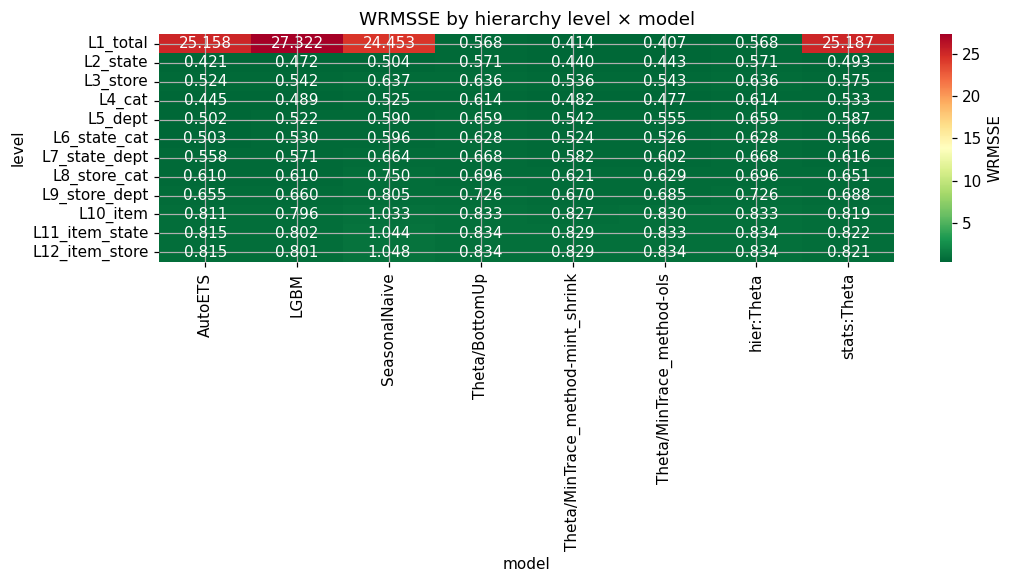

In [12]:
mean_by_level = hier[model_cols].mean(axis=0).rename('mean_WRMSSE_over_12_levels')
print('Mean WRMSSE across the 12 M5 levels (lower is better):')
print(mean_by_level.sort_values().to_string())

fig, ax = plt.subplots(figsize=(10, max(4, 0.45 * len(M5_LEVELS))))
sns.heatmap(hier[model_cols], annot=True, fmt='.3f', cmap='RdYlGn_r',
            ax=ax, cbar_kws={'label': 'WRMSSE'})
ax.set_title('WRMSSE by hierarchy level × model')
ax.set_xlabel('model')
fig.tight_layout()

## 4 · Standard accuracy metrics (MAE, RMSE, sMAPE, signed bias)

In [13]:
def conventional_metrics(eval_df: pd.DataFrame, model_cols: list[str]) -> pd.DataFrame:
    """Per-model MAE / RMSE / sMAPE / signed-bias on the bottom level."""
    rows = []
    e = eval_df.dropna(subset=['y'])
    y_true = e['y'].to_numpy()
    mean_y = float(y_true.mean()) if len(y_true) else np.nan
    for m in model_cols:
        sub = e.dropna(subset=[m])
        yt, yh = sub['y'].to_numpy(), sub[m].to_numpy()
        err = yh - yt
        denom = np.abs(yt) + np.abs(yh)
        smape = float(np.where(denom > 0, 2 * np.abs(err) / denom, 0.0).mean())
        rows.append({
            'model': m,
            'n_obs': int(len(sub)),
            'MAE': float(np.abs(err).mean()),
            'RMSE': float(np.sqrt((err ** 2).mean())),
            'sMAPE': smape,
            'bias_mean_residual': float(err.mean()),
            'bias_pct_of_mean_y': float(err.mean() / mean_y) if mean_y else np.nan,
        })
    return pd.DataFrame(rows).set_index('model').sort_values('RMSE')


conv = conventional_metrics(cv, model_cols)
(conv.style
 .format({'n_obs': '{:,d}', 'MAE': '{:.3f}', 'RMSE': '{:.3f}',
          'sMAPE': '{:.2%}', 'bias_mean_residual': '{:+.3f}', 'bias_pct_of_mean_y': '{:+.2%}'})
 .background_gradient(cmap='RdYlGn_r', subset=['MAE', 'RMSE', 'sMAPE']))

/tmp/ipykernel_134469/2710287573.py:12: RuntimeWarning: invalid value encountered in divide
  smape = float(np.where(denom > 0, 2 * np.abs(err) / denom, 0.0).mean())
/tmp/ipykernel_134469/2710287573.py:12: RuntimeWarning: invalid value encountered in divide
  smape = float(np.where(denom > 0, 2 * np.abs(err) / denom, 0.0).mean())
/tmp/ipykernel_134469/2710287573.py:12: RuntimeWarning: invalid value encountered in divide
  smape = float(np.where(denom > 0, 2 * np.abs(err) / denom, 0.0).mean())
/tmp/ipykernel_134469/2710287573.py:12: RuntimeWarning: invalid value encountered in divide
  smape = float(np.where(denom > 0, 2 * np.abs(err) / denom, 0.0).mean())
/tmp/ipykernel_134469/2710287573.py:12: RuntimeWarning: invalid value encountered in divide
  smape = float(np.where(denom > 0, 2 * np.abs(err) / denom, 0.0).mean())


,n_obs,MAE,RMSE,sMAPE,bias_mean_residual,bias_pct_of_mean_y
model,,,,,,
LGBM,"420,000",1.052,2.206,140.68%,+0.072,+5.12%
AutoETS,"420,000",1.041,2.257,142.64%,-0.024,-1.69%
stats:Theta,"420,000",1.049,2.272,142.86%,-0.018,-1.28%
Theta/MinTrace_method-mint_shrink,"420,000",1.055,2.331,144.23%,-0.033,-2.35%
Theta/MinTrace_method-ols,"420,000",1.066,2.343,144.74%,-0.026,-1.84%
hier:Theta,"420,000",1.064,2.345,141.43%,+0.004,+0.30%
Theta/BottomUp,"420,000",1.064,2.345,141.43%,+0.004,+0.30%
SeasonalNaive,"420,000",1.222,2.746,80.99%,-0.060,-4.33%


## 5 · Per-series diagnostics

In [14]:
def per_series_rmsse(eval_df: pd.DataFrame, components, model_cols: list[str]) -> pd.DataFrame:
    """RMSSE per (unique_id × model) — feeds the distribution + worst-N analyses."""
    out = {}
    for m in model_cols:
        merged = eval_df.dropna(subset=['y', m])
        mse = (merged[m] - merged['y']).pow(2).groupby(merged['unique_id'], observed=True).mean()
        common = mse.index.intersection(components.scales.index)
        out[m] = np.sqrt(mse.loc[common] / components.scales.loc[common])
    return pd.DataFrame(out)


series_rmsse = per_series_rmsse(cv, components, model_cols)
print(f'RMSSE per series — {len(series_rmsse):,d} series × {len(model_cols)} models')
series_rmsse.describe(percentiles=[0.5, 0.75, 0.9, 0.99]).T

RMSSE per series — 4,882 series × 8 models


,count,mean,std,min,50%,75%,90%,99%,max
AutoETS,4882.0,0.871543,0.579992,0.070236,0.756483,0.940406,1.255503,2.831911,16.689037
LGBM,4882.0,0.862009,0.566261,0.104126,0.754043,0.932378,1.233339,2.760527,16.231478
SeasonalNaive,4882.0,1.140976,0.717238,0.000000,1.013907,1.247549,1.639542,3.605374,20.955736
Theta/BottomUp,4882.0,0.887223,0.590791,0.018276,0.773644,0.956704,1.274679,2.896236,16.606754
Theta/MinTrace_method-mint_shrink,4882.0,0.883406,0.585333,0.019674,0.770208,0.951562,1.270866,2.886971,16.599359
Theta/MinTrace_method-ols,4882.0,0.896070,0.593561,0.036714,0.780665,0.962069,1.285904,2.913267,17.484582
hier:Theta,4882.0,0.887223,0.590791,0.018276,0.773644,0.956704,1.274679,2.896237,16.606754
stats:Theta,4882.0,0.879023,0.580893,0.004684,0.767160,0.951224,1.261719,2.879994,16.633175


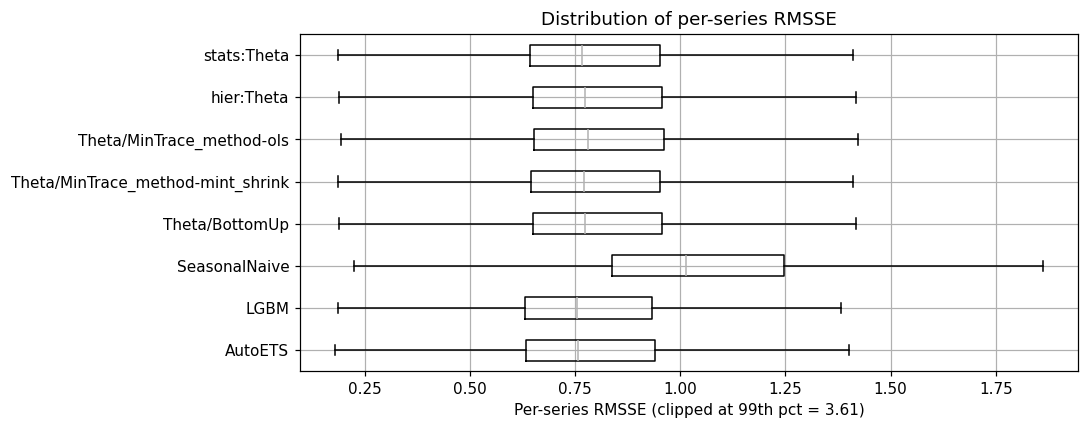

In [15]:
fig, ax = plt.subplots(figsize=(10, 4))
clip = float(series_rmsse.quantile(0.99).max())
series_rmsse.clip(upper=clip).boxplot(ax=ax, vert=False, showfliers=False)
ax.set_xlabel(f'Per-series RMSSE (clipped at 99th pct = {clip:.2f})')
ax.set_title('Distribution of per-series RMSSE')
fig.tight_layout()

In [16]:
top_n = 10
worst = pd.concat(
    {m: series_rmsse[m].sort_values(ascending=False).head(top_n).reset_index() for m in model_cols},
    axis=1,
)
worst.columns = pd.MultiIndex.from_tuples(worst.columns)
worst

AutoETS                             LGBM             \
              unique_id    AutoETS             unique_id       LGBM   
0      FOODS_3_750_WI_3  16.689037      FOODS_3_750_WI_3  16.231478   
1      FOODS_3_382_CA_3  13.088407      FOODS_3_382_CA_3  14.483538   
2      FOODS_1_081_TX_1  10.186154      FOODS_1_081_TX_1  10.013768   
3      FOODS_3_128_WI_2   9.209017      FOODS_3_128_WI_2   8.769311   
4      FOODS_3_784_CA_4   6.598340      FOODS_2_310_TX_2   6.634783   
5      FOODS_3_618_WI_2   6.575076      FOODS_3_784_CA_4   6.605811   
6      FOODS_1_105_WI_2   6.244794      FOODS_1_105_WI_2   6.357863   
7  HOUSEHOLD_2_405_TX_2   5.946492  HOUSEHOLD_2_447_CA_4   5.795014   
8      FOODS_3_630_CA_3   5.929408  HOUSEHOLD_2_405_TX_2   5.685203   
9  HOUSEHOLD_2_022_CA_1   5.906915      FOODS_3_618_WI_2   5.627473   

          SeasonalNaive                      Theta/BottomUp                 \
              unique_id SeasonalNaive             unique_id Theta/BottomUp   
0      FOODS_3_750_WI_3     20.955736      FOODS_3_750_WI_3      16.606754   
1      FOODS_3_382_CA_3     12.892718      FOODS_3_382_CA_3      13.043745   
2      FOODS_1_081_TX_1     11.984117      FOODS_1_081_TX_1      10.091906   
3      FOODS_3_128_WI_2     11.194706      FOODS_3_128_WI_2       9.277610   
4      FOODS_2_310_TX_2     10.897794      FOODS_2_310_TX_2       8.109728   
5      FOODS_3_630_CA_3      8.309489      FOODS_3_784_CA_4       6.768799   
6      FOODS_1_105_WI_2      8.267838      FOODS_3_618_WI_2       6.745832   
7  HOUSEHOLD_2_405_TX_2      7.794992      FOODS_1_105_WI_2       6.368983   
8  HOUSEHOLD_2_447_CA_4      7.750576      FOODS_3_325_CA_2       6.098720   
9  HOUSEHOLD_2_022_CA_1      7.148093  HOUSEHOLD_2_022_CA_1       6.072664   

  Theta/MinTrace_method-mint_shrink                                    \
                          unique_id Theta/MinTrace_method-mint_shrink   
0                  FOODS_3_750_WI_3                         16.599359   
1                  FOODS_3_382_CA_3                         12.951707   
2                  FOODS_1_081_TX_1                         10.043916   
3                  FOODS_3_128_WI_2                          9.319068   
4                  FOODS_2_310_TX_2                          7.554204   
5                  FOODS_3_618_WI_2                          6.690549   
6                  FOODS_3_784_CA_4                          6.644018   
7                  FOODS_1_105_WI_2                          6.367097   
8              HOUSEHOLD_2_022_CA_1                          6.060785   
9              HOUSEHOLD_2_447_CA_4                          5.995312   

  Theta/MinTrace_method-ols                                      hier:Theta  \
                  unique_id Theta/MinTrace_method-ols             unique_id   
0          FOODS_3_750_WI_3                 17.484582      FOODS_3_750_WI_3   
1          FOODS_3_382_CA_3                 13.018587      FOODS_3_382_CA_3   
2          FOODS_1_081_TX_1                 10.059674      FOODS_1_081_TX_1   
3          FOODS_3_128_WI_2                  9.549359      FOODS_3_128_WI_2   
4          FOODS_2_310_TX_2                  7.382235      FOODS_2_310_TX_2   
5          FOODS_3_784_CA_4                  6.737571      FOODS_3_784_CA_4   
6          FOODS_3_618_WI_2                  6.732189      FOODS_3_618_WI_2   
7          FOODS_1_105_WI_2                  6.252490      FOODS_1_105_WI_2   
8      HOUSEHOLD_2_447_CA_4                  6.048406      FOODS_3_325_CA_2   
9      HOUSEHOLD_2_022_CA_1                  6.003095  HOUSEHOLD_2_022_CA_1   

                       stats:Theta              
  hier:Theta             unique_id stats:Theta  
0  16.606754      FOODS_3_750_WI_3   16.633175  
1  13.043746      FOODS_3_382_CA_3   13.051528  
2  10.091906      FOODS_1_081_TX_1   10.095269  
3   9.277610      FOODS_3_128_WI_2    9.304962  
4   8.109728      FOODS_3_618_WI_2    6.587211  
5   6.768799      FOODS_3_784_CA_4    6.586490  
6   6.74

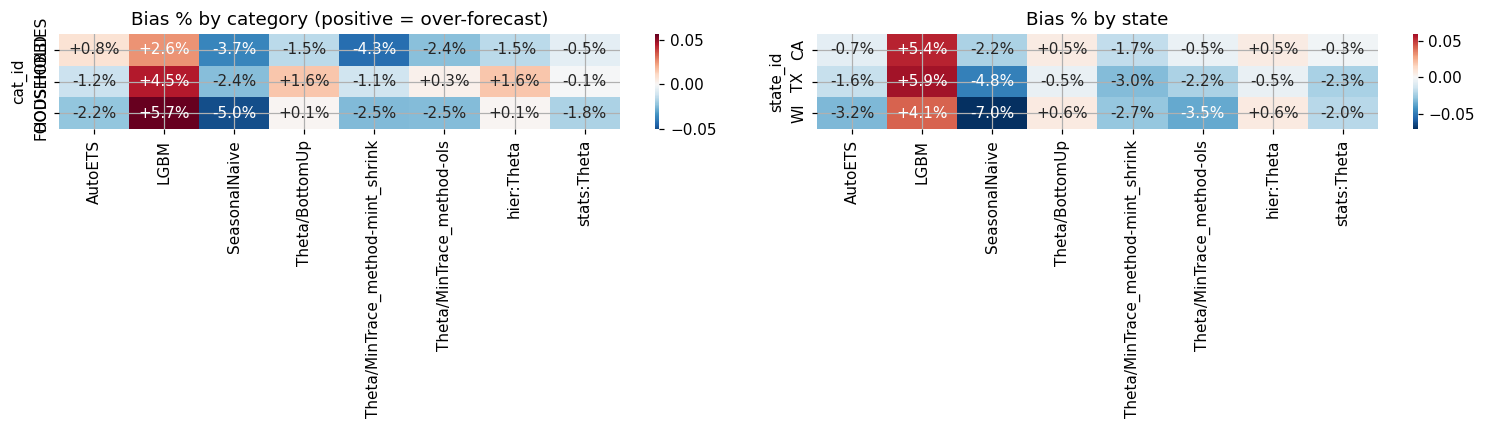

In [17]:
cv_static = cv.merge(statics, on='unique_id', how='left')


def bias_by(group_col: str) -> pd.DataFrame:
    rows = []
    for m in model_cols:
        g = cv_static.dropna(subset=['y', m]).groupby(group_col, observed=True)
        bias = (g[m].mean() - g['y'].mean()) / g['y'].mean().replace(0, np.nan)
        bias.name = m
        rows.append(bias)
    out = pd.concat(rows, axis=1)
    out.index.name = group_col
    return out


bias_cat = bias_by('cat_id')
bias_state = bias_by('state_id')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.heatmap(bias_cat, annot=True, fmt='+.1%', cmap='RdBu_r', center=0, ax=axes[0])
axes[0].set_title('Bias % by category (positive = over-forecast)')
sns.heatmap(bias_state, annot=True, fmt='+.1%', cmap='RdBu_r', center=0, ax=axes[1])
axes[1].set_title('Bias % by state')
fig.tight_layout()

## 6 · Predicted vs actual

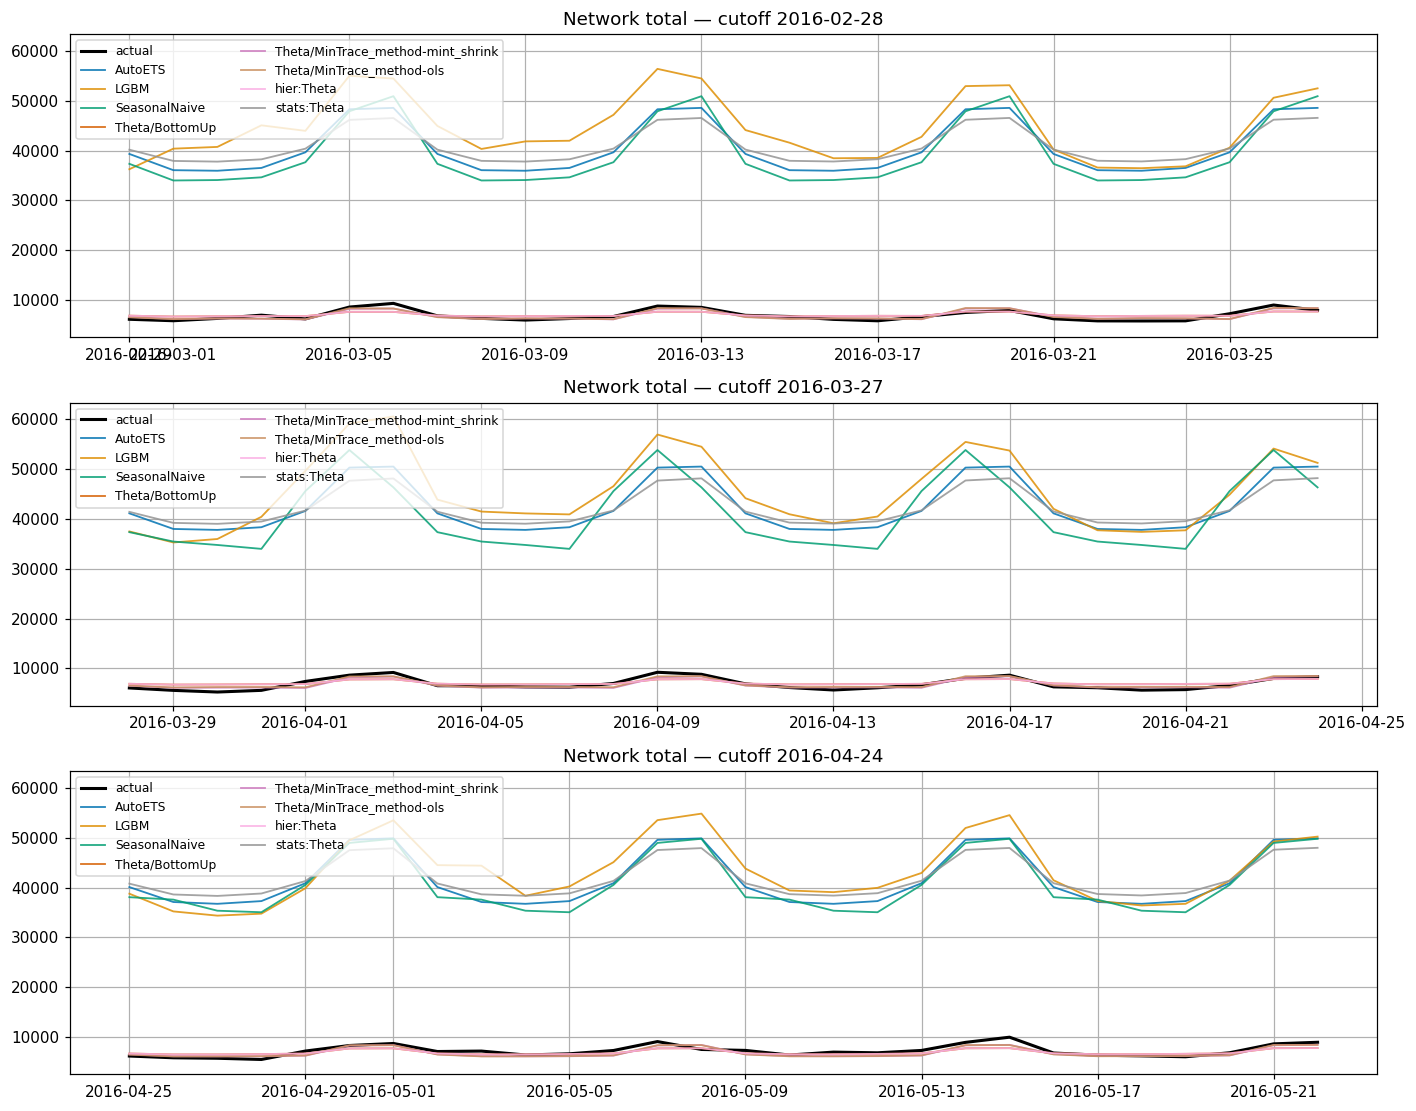

In [18]:
network = cv.groupby(['cutoff', 'ds'], observed=True)[['y', *model_cols]].sum().reset_index()
cutoffs = sorted(network['cutoff'].unique())

fig, axes = plt.subplots(len(cutoffs), 1, figsize=(13, 3.4 * len(cutoffs)),
                         sharey=True, squeeze=False)
for ax, cut in zip(axes[:, 0], cutoffs):
    sub = network[network['cutoff'] == cut].sort_values('ds')
    ax.plot(sub['ds'], sub['y'], color='black', lw=2.0, label='actual')
    for m in model_cols:
        ax.plot(sub['ds'], sub[m], lw=1.2, alpha=0.85, label=m)
    ax.set_title(f'Network total — cutoff {pd.Timestamp(cut).date()}')
    ax.legend(loc='upper left', fontsize=8, ncol=2)
fig.tight_layout()

Top 5 series by trailing dollar-sales weight: ['FOODS_1_096_WI_2', 'HOBBIES_1_354_TX_2', 'HOBBIES_1_354_CA_1', 'FOODS_3_120_WI_3', 'FOODS_3_282_CA_3']


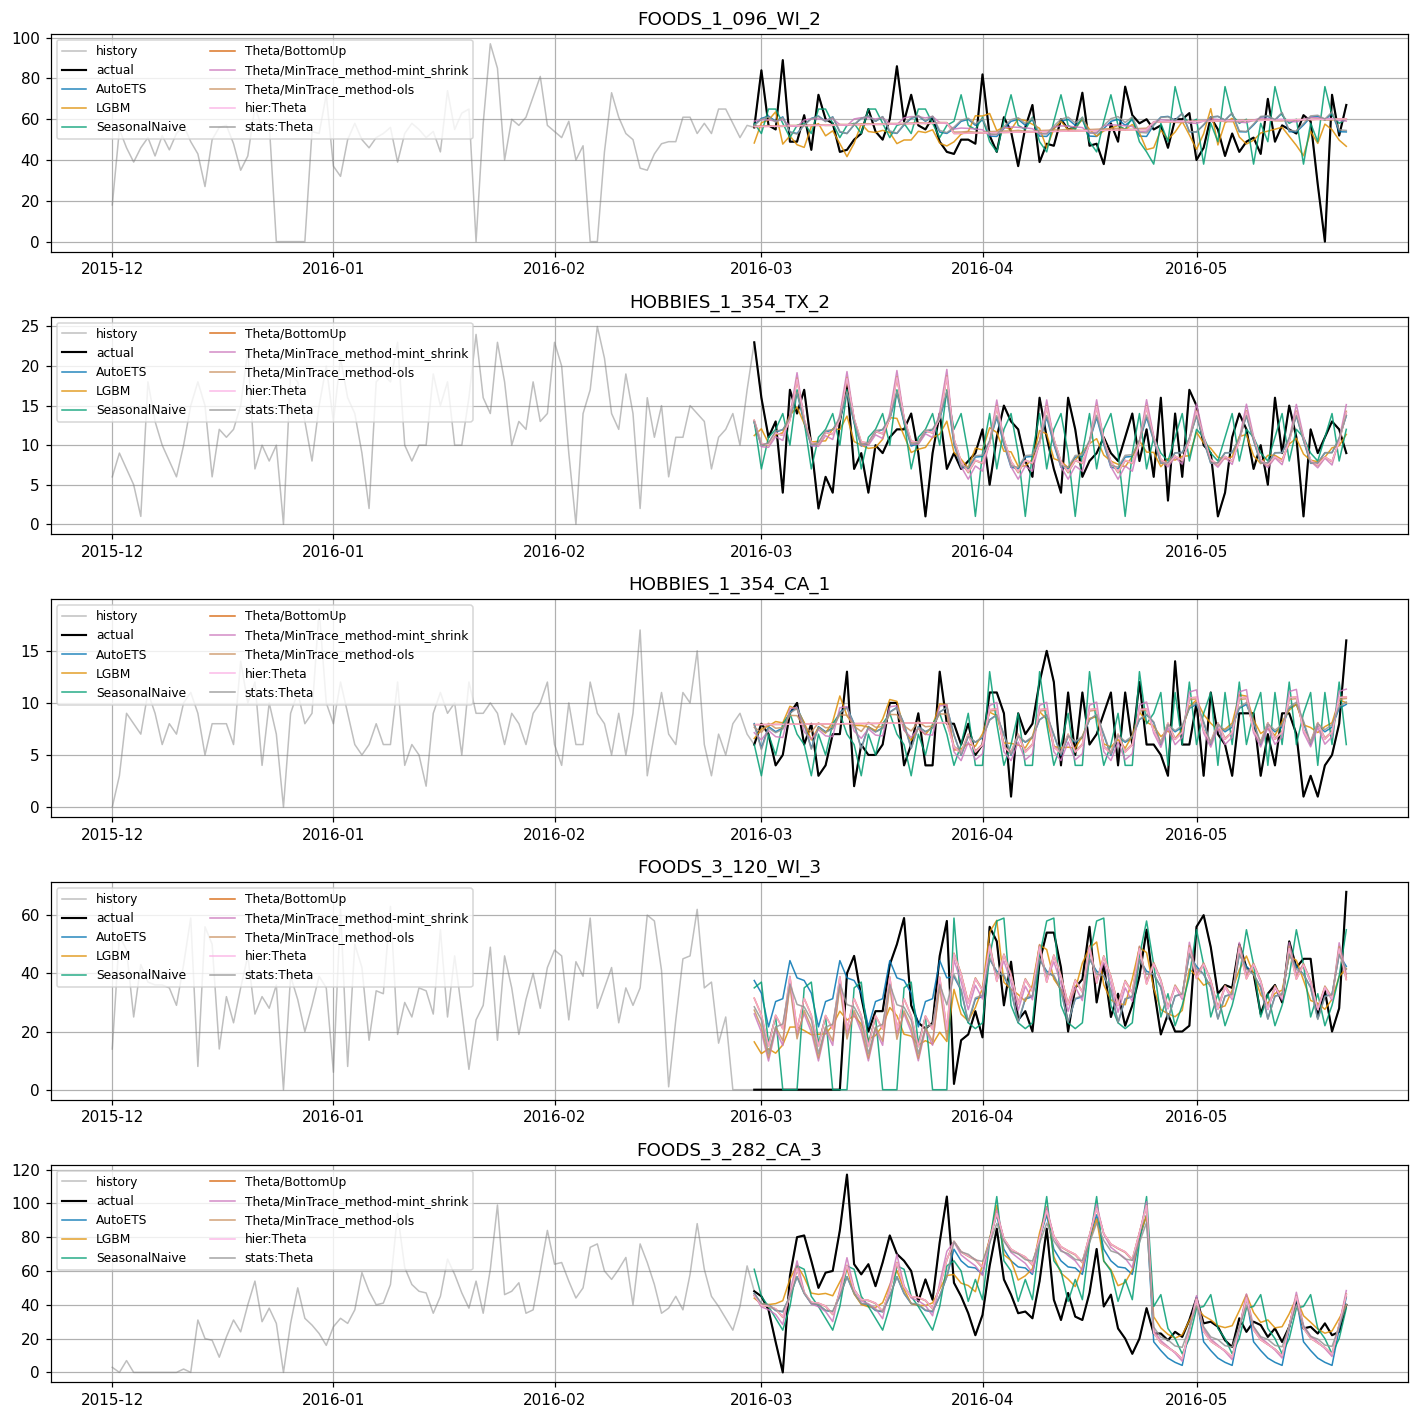

In [19]:
top_k = 5
top_ids = components.weights.sort_values(ascending=False).head(top_k).index.tolist()
print(f'Top {top_k} series by trailing dollar-sales weight: {top_ids}')

history_cutoff = cv['ds'].min() - pd.Timedelta(days=90)
history = long[(long['unique_id'].isin(top_ids)) & (long['ds'] >= history_cutoff)]

fig, axes = plt.subplots(top_k, 1, figsize=(13, 2.6 * top_k), sharex=False)
for ax, uid in zip(np.atleast_1d(axes), top_ids):
    h = history[history['unique_id'] == uid].sort_values('ds')
    ax.plot(h['ds'], h['y'], color='grey', lw=1.0, alpha=0.5, label='history')
    sub = cv[cv['unique_id'] == uid].sort_values('ds')
    ax.plot(sub['ds'], sub['y'], color='black', lw=1.4, label='actual')
    for m in model_cols:
        ax.plot(sub['ds'], sub[m], lw=1.0, alpha=0.85, label=m)
    ax.set_title(uid)
    ax.legend(loc='upper left', fontsize=8, ncol=2)
fig.tight_layout()

## 7 · Persist scoring summary

In [20]:
mean_by_level = hier[model_cols].mean(axis=0).rename('mean_WRMSSE_over_12_levels')

summary = pd.concat(
    {
        'WRMSSE_bottom': bottom_scores,
        'WRMSSE_mean_12L': mean_by_level,
        **{f'WRMSSE_{lvl}': hier.loc[lvl, model_cols] for lvl in hier.index},
        'MAE': conv['MAE'],
        'RMSE': conv['RMSE'],
        'sMAPE': conv['sMAPE'],
        'bias_pct_of_mean_y': conv['bias_pct_of_mean_y'],
    },
    axis=1,
).rename_axis('model').sort_values('WRMSSE_bottom')

ARTIFACTS.mkdir(parents=True, exist_ok=True)
summary.to_parquet(SCORING_OUT)
print(f'wrote {SCORING_OUT}  ({summary.shape[0]} models × {summary.shape[1]} metrics)')
summary.style.format('{:.4f}').background_gradient(cmap='RdYlGn_r')

wrote /home/ricka/Git/GitHub/M5/artifacts/scoring_summary.parquet  (8 models × 18 metrics)


,WRMSSE_bottom,WRMSSE_mean_12L,WRMSSE_L1_total,WRMSSE_L2_state,WRMSSE_L3_store,WRMSSE_L4_cat,WRMSSE_L5_dept,WRMSSE_L6_state_cat,WRMSSE_L7_state_dept,WRMSSE_L8_store_cat,WRMSSE_L9_store_dept,WRMSSE_L10_item,WRMSSE_L11_item_state,WRMSSE_L12_item_store,MAE,RMSE,sMAPE,bias_pct_of_mean_y
model,,,,,,,,,,,,,,,,,,
LGBM,0.8005,2.8430,27.3218,0.4717,0.5425,0.4894,0.5217,0.5295,0.5711,0.6100,0.6600,0.7961,0.8015,0.8005,1.0516,2.2055,1.4068,0.0512
AutoETS,0.8147,2.6514,25.1581,0.4210,0.5243,0.4451,0.5016,0.5033,0.5578,0.6105,0.6547,0.8111,0.8149,0.8147,1.0412,2.2572,1.4264,-0.0169
stats:Theta,0.8212,2.6967,25.1872,0.4934,0.5754,0.5330,0.5867,0.5665,0.6162,0.6514,0.6883,0.8189,0.8218,0.8212,1.0495,2.2718,1.4286,-0.0128
Theta/MinTrace_method-mint_shrink,0.8294,0.6080,0.4137,0.4403,0.5360,0.4816,0.5418,0.5236,0.5819,0.6212,0.6703,0.8266,0.8292,0.8294,1.0552,2.3309,1.4423,-0.0235
hier:Theta,0.8337,0.6889,0.5684,0.5710,0.6361,0.6136,0.6595,0.6277,0.6680,0.6958,0.7255,0.8334,0.8344,0.8337,1.0642,2.3454,1.4143,0.0030
Theta/BottomUp,0.8337,0.6889,0.5684,0.5710,0.6361,0.6136,0.6595,0.6277,0.6680,0.6958,0.7255,0.8334,0.8344,0.8337,1.0642,2.3454,1.4143,0.0030
Theta/MinTrace_method-ols,0.8341,0.6137,0.4074,0.4432,0.5434,0.4768,0.5548,0.5265,0.6016,0.6291,0.6849,0.8300,0.8329,0.8341,1.0660,2.3434,1.4474,-0.0184
SeasonalNaive,1.0482,2.7208,24.4532,0.5044,0.6368,0.5252,0.5903,0.5960,0.6643,0.7495,0.8051,1.0331,1.0439,1.0482,1.2215,2.7455,0.8099,-0.0433


## 8 · Competition benchmarks

Compare your solutions against the top M5 competition submissions. The official metric is the **average WRMSSE across 12 hierarchy levels**, not the bottom-level score alone.

Sources: M5 Accuracy private leaderboard, Makridakis et al. (2022).

In [21]:
competition_benchmarks = pd.DataFrame({
    'WRMSSE_mean_12L': {
        '1st_place (YJ_STU)':   0.520,
        '2nd_place (Anderer)':  0.528,
        '3rd_place (mf)':       0.536,
    }
})

all_scores = pd.concat([summary[['WRMSSE_mean_12L']], competition_benchmarks])
all_scores = all_scores.sort_values('WRMSSE_mean_12L')

print('Comparison vs. M5 competition top submissions:')
print('(official metric: WRMSSE averaged across 12 hierarchy levels)')
print(all_scores.to_string(float_format=lambda x: f'{x:.4f}'))
print()

your_best = all_scores.loc[~all_scores.index.str.contains('place'), 'WRMSSE_mean_12L'].min()
first_best = 0.520
print(f'Your best vs. 1st place: {your_best:.4f} vs. {first_best:.4f}  (gap: {your_best - first_best:+.4f})')

Comparison vs. M5 competition top submissions:
(official metric: WRMSSE averaged across 12 hierarchy levels)
                                   WRMSSE_mean_12L
1st_place (YJ_STU)                          0.5200
2nd_place (Anderer)                         0.5280
3rd_place (mf)                              0.5360
Theta/MinTrace_method-mint_shrink           0.6080
Theta/MinTrace_method-ols                   0.6137
Theta/BottomUp                              0.6889
hier:Theta                                  0.6889
AutoETS                                     2.6514
stats:Theta                                 2.6967
SeasonalNaive                               2.7208
LGBM                                        2.8430

Your best vs. 1st place: 0.6080 vs. 0.5200  (gap: +0.0880)
